In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.linewidth': 1.2,
    'grid.alpha': 0.4,
    'figure.dpi': 150
})

In [2]:
def j0_sinc(x):
    """
    Calcula la función sinc(x) = sin(x)/x de forma vectorizada y segura.
    Evita la división por cero en x=0 asignando el límite matemático 1.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(x) < 1e-12, 1.0, np.sin(x) / x)

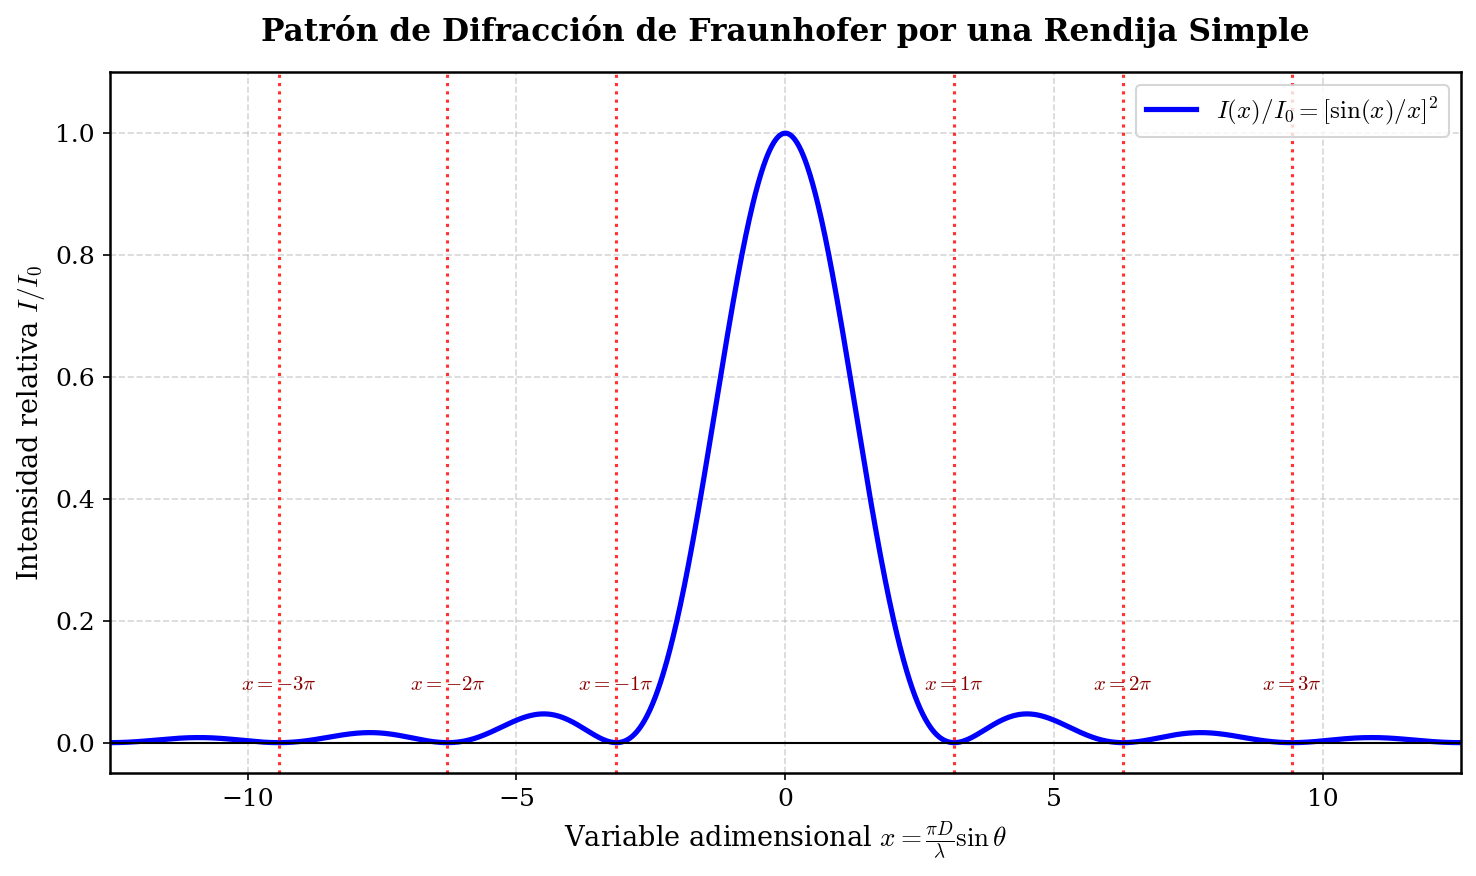

In [4]:
# =============================================================================
# GRÁFICO 1: Patrón de intensidad y localización de los mínimos de difracción
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

x = np.linspace(-4*np.pi, 4*np.pi, 2000)
I = j0_sinc(x)**2

ax1.plot(x, I, 'b-', linewidth=2.5, label=r'$I(x)/I_0 = [\sin(x)/x]^2$')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xlabel(r'Variable adimensional $x = \frac{\pi D}{\lambda} \sin\theta$', fontsize=13)
ax1.set_ylabel(r'Intensidad relativa $I/I_0$', fontsize=13)
ax1.set_title('Patrón de Difracción de Fraunhofer por una Rendija Simple', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylim(-0.05, 1.1)
ax1.set_xlim(-4*np.pi, 4*np.pi)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize=12)

# Marcar los ceros de la función (mínimos de difracción)
n_vals = [-3, -2, -1, 1, 2, 3]
for n in n_vals:
    xm = n * np.pi
    ax1.axvline(xm, color='r', linestyle=':', linewidth=1.5, alpha=0.8)
    ax1.annotate(f'$x={n}\\pi$', xy=(xm, 0.08), ha='center', va='bottom', fontsize=10, color='darkred')

plt.tight_layout()
plt.savefig('grafico1_intensidad_difraccion.png', dpi=300)
plt.show()


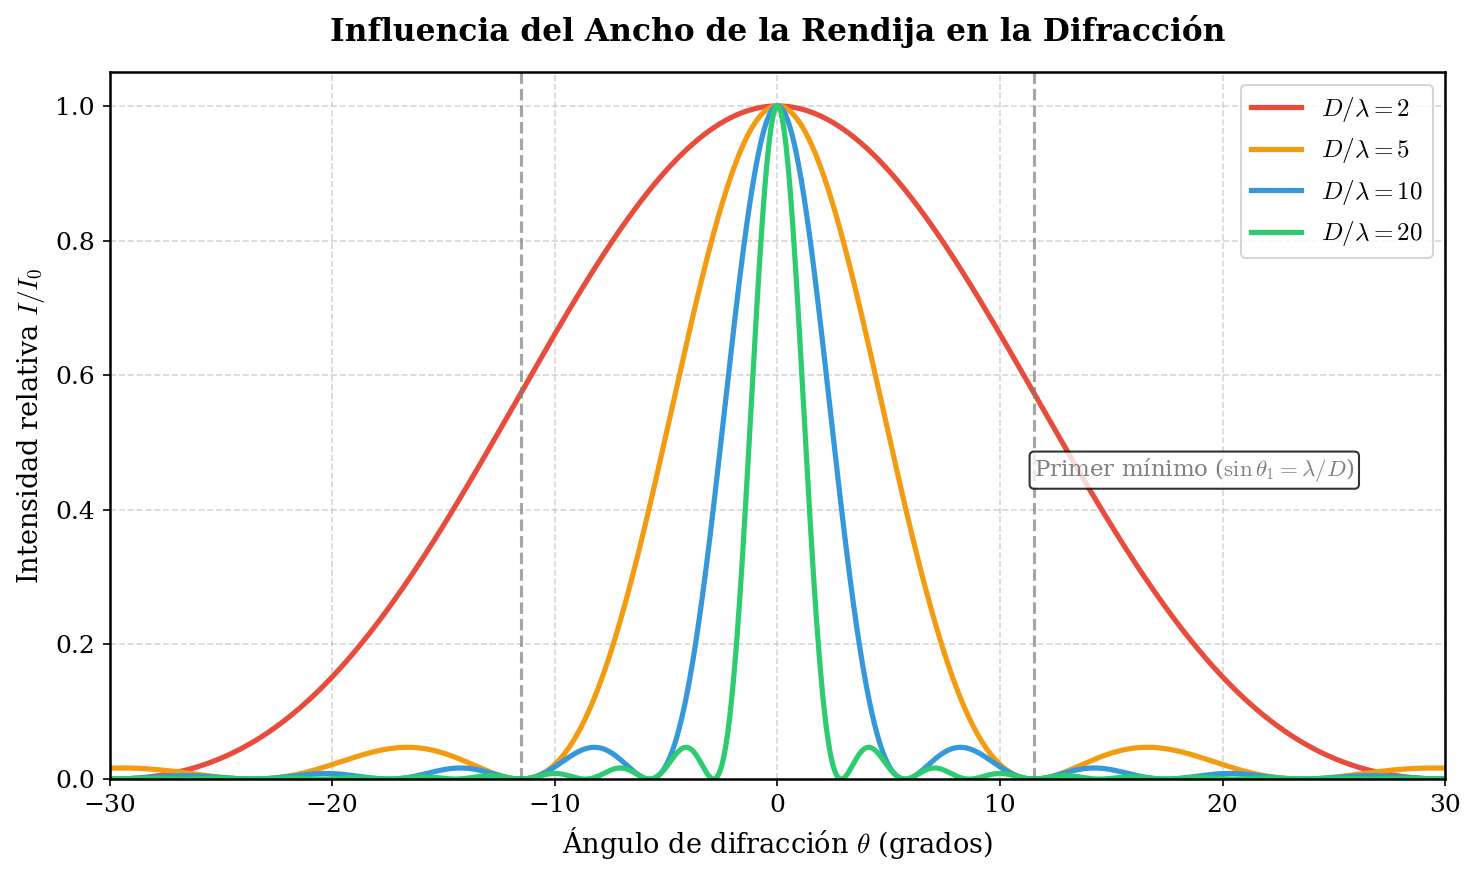

In [5]:
# =============================================================================
# GRÁFICO 2: Efecto del tamaño de la rendija (relación D/λ)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

theta_deg = np.linspace(-30, 30, 1500)
theta_rad = np.radians(theta_deg)

ratios = [2, 5, 10, 20]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
labels = [r'$D/\lambda = 2$', r'$D/\lambda = 5$', r'$D/\lambda = 10$', r'$D/\lambda = 20$']

for ratio, color, label in zip(ratios, colors, labels):
    x = np.pi * ratio * np.sin(theta_rad)
    I = j0_sinc(x)**2
    ax2.plot(theta_deg, I, color=color, linewidth=2.5, label=label)

ax2.set_xlabel(r'Ángulo de difracción $\theta$ (grados)', fontsize=13)
ax2.set_ylabel(r'Intensidad relativa $I/I_0$', fontsize=13)
ax2.set_title('Influencia del Ancho de la Rendija en la Difracción', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlim(-30, 30)
ax2.set_ylim(0, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=12, loc='upper right')

# Línea del primer mínimo para el caso D/λ = 5
theta1 = np.degrees(np.arcsin(1/5))
ax2.axvline(theta1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(-theta1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.annotate(r'Primer mínimo ($\sin\theta_1 = \lambda/D$)', xy=(theta1, 0.45), fontsize=11,
             ha='left', color='gray',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('grafico2_efecto_ancho_rendija.png', dpi=300)
plt.show()

In [7]:
def airy_intensity(r):
    """
    Intensidad normalizada del patrón de Airy: I(r) = [2*J1(r)/r]^2
    r: coordenada radial adimensional (r = k*a*sinθ)
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(r < 1e-12, 1.0, (2 * j1(r) / r)**2)

In [12]:
# Crear grid
N = 800
x = np.linspace(-20, 20, N)
y = np.linspace(-20, 20, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
I = airy_intensity(R)

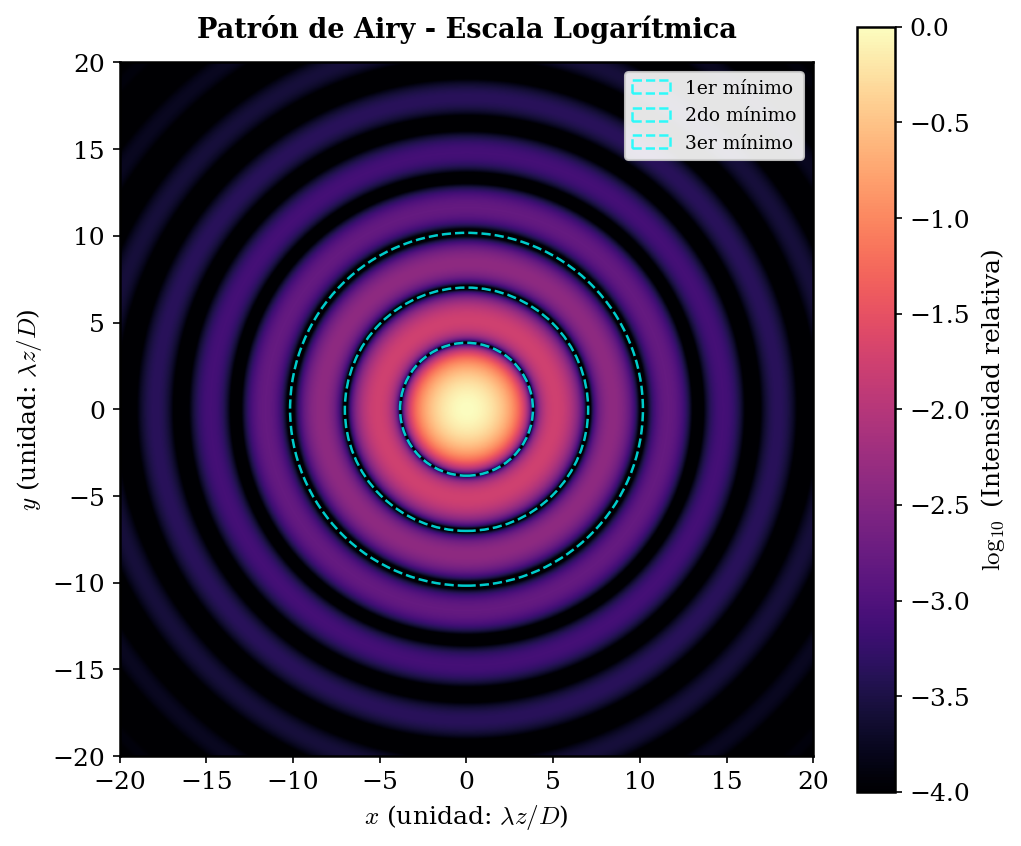

In [15]:
# =============================================================================
# GRÁFICO 1: Escala logarítmica (REVELA los anillos)
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(7, 6))

# Usar escala logarítmica para hacer visibles los anillos débiles
I_log = np.log10(I + 1e-10)  # Pequeño offset para evitar log(0)

im1 = ax1.imshow(I_log, extent=[-20, 20, -20, 20], origin='lower',
                 cmap='magma', interpolation='bilinear',
                 norm=plt.Normalize(vmin=-4, vmax=0))  # Mostrar 4 órdenes de magnitud

ax1.set_xlabel(r'$x$ (unidad: $\lambda z / D$)', fontsize=12)
ax1.set_ylabel(r'$y$ (unidad: $\lambda z / D$)', fontsize=12)
ax1.set_title('Patrón de Airy - Escala Logarítmica', 
              fontsize=13, fontweight='bold', pad=12)
ax1.set_aspect('equal')

# Marcar primeros mínimos
r1, r2, r3 = 3.8317, 7.0156, 10.1735
for r, label in [(r1, '1er'), (r2, '2do'), (r3, '3er')]:
    circle = plt.Circle((0, 0), r, color='cyan', fill=False, linestyle='--', 
                       linewidth=1.2, alpha=0.8, label=f'{label} mínimo')
    ax1.add_patch(circle)

ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
cbar1 = plt.colorbar(im1, ax=ax1, label=r'$\log_{10}$ (Intensidad relativa)')
plt.tight_layout()
plt.savefig('airy_log_scale.png', dpi=300, bbox_inches='tight')
plt.show()


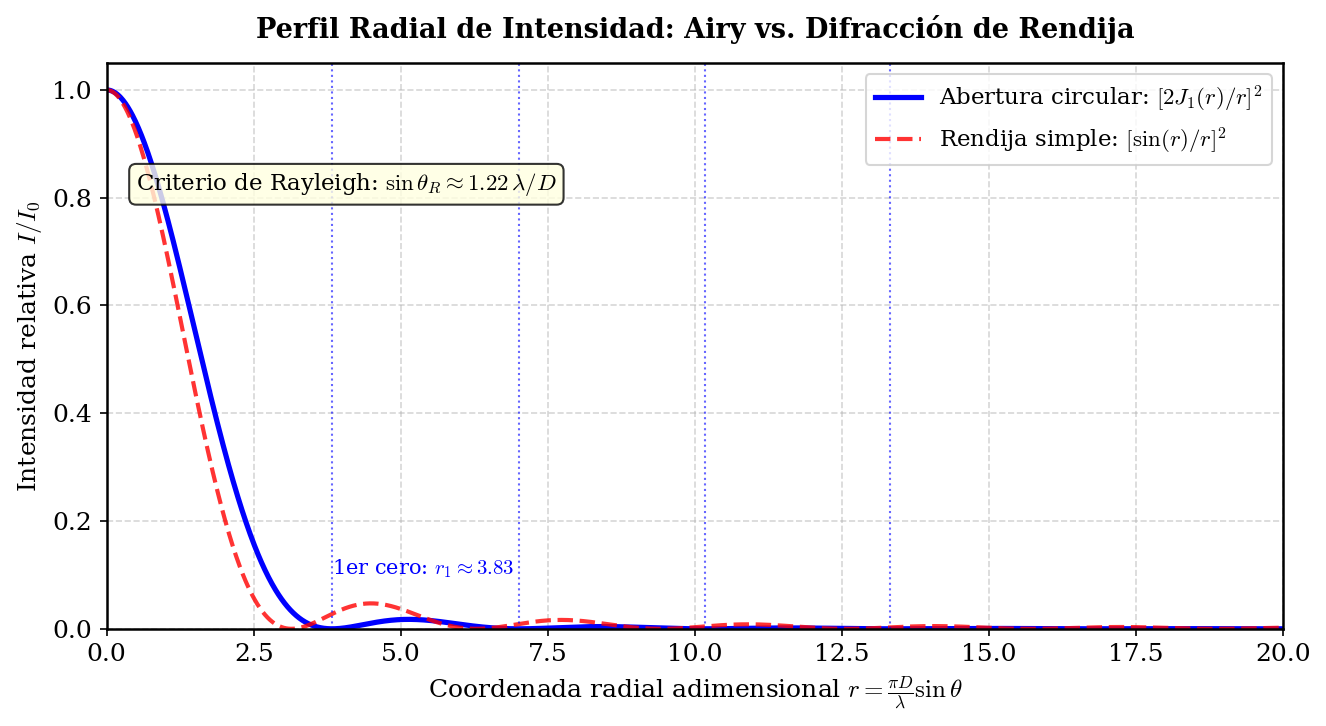

In [9]:
# =============================================================================
# GRÁFICO 2: Perfil radial + comparación con rendija simple
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

r = np.linspace(0, 20, 2000)
I_airy = airy_intensity(r)
I_slit = (np.sinc(r / np.pi))**2  # sinc(x) = sin(x)/x, ceros en n*pi

ax2.plot(r, I_airy, 'b-', linewidth=2.5, label='Abertura circular: $[2J_1(r)/r]^2$')
ax2.plot(r, I_slit, 'r--', linewidth=2, alpha=0.8, label='Rendija simple: $[\\sin(r)/r]^2$')
ax2.set_xlabel(r'Coordenada radial adimensional $r = \frac{\pi D}{\lambda} \sin\theta$', fontsize=12)
ax2.set_ylabel(r'Intensidad relativa $I/I_0$', fontsize=12)
ax2.set_title('Perfil Radial de Intensidad: Airy vs. Difracción de Rendija', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

# Marcar primeros ceros del patrón de Airy (ceros de J1)
zeros_J1 = [3.8317, 7.0156, 10.1735, 13.3237]
for z in zeros_J1:
    ax2.axvline(z, color='b', linestyle=':', linewidth=1, alpha=0.6)
ax2.annotate(r'1er cero: $r_1 \approx 3.83$', xy=(3.83, 0.1), ha='left', fontsize=10, color='blue')

# Anotar criterio de Rayleigh
ax2.annotate(r'Criterio de Rayleigh: $\sin\theta_R \approx 1.22\,\lambda/D$', 
             xy=(0.5, 0.85), fontsize=11, va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()